# HCC Internal Diagnostics (from logs)

This notebook reads `run_log.jsonl` and analyzes the new diagnostic signals added to understand the CUB/Aircraft degradation with HCC.

Runs used (main):
- baseline
- `step@0`
- `step@100`


## HCC New Log Glossary

These metrics are saved in `run_log.jsonl` (`train_metrics` / `val_metrics`) and in `test_metrics.yaml`.

### Conventions

- `GT` means **ground truth** (the true dataset label).
- `pre`: distribution from `softmax(logits)` before the HCC effect.
- `post`: final scores used by metrics (`effective_probs_per_level` when present).
- `ind`: independent decoding.
- `td`: top-down decoding.
- Levels: `L0` coarse, `L1` middle, `L2` fine.

### Constraint state / scheduling

- `proj_constraint_alpha`: HCC constraint intensity (`0`=off, `1`=fully hard).
- `proj_temperature`: current temperature in the HCC schedule.

### Constraint residuals (projector)

- `proj_residual_before_l1`: mean absolute constraint violation before correction.
  - formula: `mean(abs([M12*p2 - p1, M23*p3 - p2]))`
- `proj_residual_after_l1`: same quantity after correction.
- `proj_residual_reduction`: residual reduction (`before - after`).

### Fine-distribution shift (`L2`) glossary

This block measures how much HCC changes the fine-level probability vector from `pre` to `post`.

- `proj_delta_l1_level_2`
  - Definition: mean `L1` distance between `p_fine_pre` and `p_fine_post`.
  - Reading: larger value = stronger redistribution of probability mass across fine classes.

- `proj_flip_rate_level_2`
  - Definition: fraction of samples where fine-level `argmax` changes (`pre -> post`).
  - Reading: larger value = HCC changes the predicted fine class more often.

- `proj_gt_prob_delta_level_2`
  - Definition: mean change on GT fine-class probability (`post - pre`).
  - Reading:
    - positive => GT fine class gained probability,
    - negative => GT fine class lost probability.

Worked example (one sample):

- `pre  = [cat 0.55, dog 0.25, fox 0.15, wolf 0.05]`
- `post = [cat 0.35, dog 0.45, fox 0.15, wolf 0.05]`

Interpretation:

- `proj_delta_l1_level_2` is large (probability moved from `cat` to `dog`).
- `proj_flip_rate_level_2` would count this as a flip (`cat -> dog`).
- If GT is `cat`, then `proj_gt_prob_delta_level_2 = 0.35 - 0.55 = -0.20` (worse for GT).

### Accuracy conditioned on correct parent

- `acc_l2_ind_given_l1_correct`: fine-level independent accuracy conditioned on correct `L1`.
- `acc_l2_td_given_l1_correct`: fine-level top-down accuracy conditioned on correct `L1`.
- `support_l1_ind_correct`: support for the condition in independent decoding.
- `support_l1_td_correct`: support for the condition in top-down decoding.

### GT-parent mass and sibling ranking (`L2`) glossary

These metrics answer two separate questions:

1. Did mass move into the correct GT parent subtree?
2. Inside that subtree, is the GT fine child ranked well among siblings?

- `gt_parent_mass_pre_l2`
  - Definition: fine-level probability mass inside the GT parent subtree (pre).

- `gt_parent_mass_post_l2`
  - Definition: same mass after HCC (post).
  - Reading: increase usually means better parent-branch concentration.

- `gt_child_rank_within_parent_pre_l2`
  - Definition: GT fine-child rank among siblings under GT parent (pre).
  - Best value: `1` (GT child is top-ranked among siblings).

- `gt_child_rank_within_parent_post_l2`
  - Definition: same rank after HCC (post).
  - Reading: lower is better; higher means sibling discrimination worsened.

### Quick reading for CUB / Aircraft

Typical pattern of independent-decoding degradation with hard HCC:

1. `gt_parent_mass_post_l2` increases,
2. `gt_child_rank_within_parent_post_l2` worsens (higher),
3. `acc_l2_ind_given_l1_correct` drops while `acc_l2_td_given_l1_correct` stays high.

Interpretation: the hierarchical path remains coherent, but fine-level sibling ranking gets worse.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

REPO_ROOT = Path('/home/g.saggini1/lexicographic_deep_learning_detailed_study')
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')

RUN_GROUPS = {
    'cifar100': {
        'baseline': OUTPUTS_ROOT / 'hcast_cifar100',
        'hcc_step0': OUTPUTS_ROOT / 'hcast_hcc_cifar100_step_0epoch',
        'hcc_step100': OUTPUTS_ROOT / 'hcast_hcc_cifar100_step_100epochs',
    },
    'cub200': {
        'baseline': OUTPUTS_ROOT / 'hcast_cub200',
        'hcc_step0': OUTPUTS_ROOT / 'hcast_hcc_cub200_step_0epoch',
        'hcc_step100': OUTPUTS_ROOT / 'hcast_hcc_cub200_step_100epochs',
    },
    'aircraft': {
        'baseline': OUTPUTS_ROOT / 'hcast_aircraft',
        'hcc_step0': OUTPUTS_ROOT / 'hcast_hcc_aircraft_step_0epoch',
        'hcc_step100': OUTPUTS_ROOT / 'hcast_hcc_aircraft_step_100epochs',
    },
}

CORE_DEBUG_METRICS = [
    'proj_constraint_alpha',
    'proj_temperature',
    'proj_residual_before_l1',
    'proj_residual_after_l1',
    'proj_residual_reduction',
    'proj_delta_l1_level_2',
    'proj_flip_rate_level_2',
    'proj_gt_prob_delta_level_2',
    'acc_l2_ind_given_l1_correct',
    'acc_l2_td_given_l1_correct',
    'support_l1_ind_correct',
    'support_l1_td_correct',
    'gt_parent_mass_pre_l2',
    'gt_parent_mass_post_l2',
    'gt_child_rank_within_parent_pre_l2',
    'gt_child_rank_within_parent_post_l2',
    'acc_level_independent_2',
    'acc_level_topdown_2',
    'fpa_topdown',
    'loss_level_2',
    'gk_loss',
]


In [2]:
def load_jsonl(path: Path):
    events = []
    if not path.exists():
        return events
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            events.append(json.loads(line))
    return events


def events_to_epoch_df(run_dir: Path, split: str = 'val') -> pd.DataFrame:
    events = load_jsonl(run_dir / 'run_log.jsonl')
    rows = []
    for event in events:
        if event.get('event') != 'epoch':
            continue
        epoch = int(event['epoch'])
        if split == 'train':
            train_losses = event.get('train_losses', {}) or {}
            train_metrics = event.get('train_metrics', {}) or {}
            metrics = {**train_losses, **train_metrics}
        else:
            metrics = event.get('val_metrics', {}) or {}
        row = {'epoch': epoch, 'run': run_dir.name}
        for k, v in metrics.items():
            try:
                row[k] = float(v)
            except (TypeError, ValueError):
                pass
        rows.append(row)
    if not rows:
        return pd.DataFrame(columns=['epoch', 'run'])
    df = pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)
    return df


def load_dataset_group(dataset_key: str, split: str = 'val'):
    group = RUN_GROUPS[dataset_key]
    out = {}
    for label, run_dir in group.items():
        out[label] = events_to_epoch_df(run_dir, split=split)
    return out


def metric_available(group_frames, metric: str) -> bool:
    for df in group_frames.values():
        if metric in df.columns:
            return True
    return False


In [3]:
def _slice_epoch_window(df: pd.DataFrame, epoch_min=None, epoch_max=None) -> pd.DataFrame:
    use = df
    if epoch_min is not None:
        use = use[use['epoch'] >= epoch_min]
    if epoch_max is not None:
        use = use[use['epoch'] <= epoch_max]
    return use


def plot_metric_grid(dataset_key: str, metrics, split='val', epoch_min=None, epoch_max=None):
    frames = load_dataset_group(dataset_key, split=split)
    valid_metrics = [m for m in metrics if metric_available(frames, m)]
    if not valid_metrics:
        print(f'No requested metrics found for {dataset_key} ({split}).')
        return

    n = len(valid_metrics)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), squeeze=False)

    for idx, metric in enumerate(valid_metrics):
        ax = axes[idx // cols][idx % cols]
        for label, df in frames.items():
            if metric not in df.columns or df.empty:
                continue
            use = _slice_epoch_window(df, epoch_min=epoch_min, epoch_max=epoch_max)
            if use.empty:
                continue
            ax.plot(use['epoch'], use[metric], marker='o', markersize=3, linewidth=1.6, label=label)
        ax.set_title(f'{dataset_key} | {metric} ({split})')
        ax.set_xlabel('epoch')
        ax.set_ylabel(metric)
        ax.legend()

    for j in range(n, rows * cols):
        axes[j // cols][j % cols].axis('off')

    plt.tight_layout()
    plt.show()


def plot_mode_pairs(dataset_key: str, pair_specs, split='val', epoch_min=None, epoch_max=None):
    # Plot independent/top-down metrics on the same axis (similar to hcast_analysis).
    frames = load_dataset_group(dataset_key, split=split)

    valid_specs = []
    for m_ind, m_td, title in pair_specs:
        has_any = any((m_ind in df.columns) or (m_td in df.columns) for df in frames.values())
        if has_any:
            valid_specs.append((m_ind, m_td, title))

    if not valid_specs:
        print(f'No paired mode metrics found for {dataset_key} ({split}).')
        return

    n = len(valid_specs)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), squeeze=False)

    run_order = ['baseline', 'hcc_step0', 'hcc_step100']
    color_map = {
        'baseline': '#1f77b4',
        'hcc_step0': '#d62728',
        'hcc_step100': '#2ca02c',
    }

    for idx, (m_ind, m_td, title) in enumerate(valid_specs):
        ax = axes[idx // cols][idx % cols]

        for run_label in run_order:
            if run_label not in frames:
                continue
            df = frames[run_label]
            if df.empty:
                continue

            use = _slice_epoch_window(df, epoch_min=epoch_min, epoch_max=epoch_max)
            if use.empty:
                continue

            color = color_map.get(run_label, None)
            if m_ind in use.columns:
                ax.plot(
                    use['epoch'],
                    use[m_ind],
                    linestyle='--',
                    linewidth=1.8,
                    color=color,
                    label=f'{run_label} (independent)',
                )
            if m_td in use.columns:
                ax.plot(
                    use['epoch'],
                    use[m_td],
                    linestyle='-',
                    linewidth=2.0,
                    color=color,
                    label=f'{run_label} (top-down)',
                )

        ax.set_title(f'{dataset_key} | {title} ({split})')
        ax.set_xlabel('epoch')
        ax.set_ylabel(title)
        ax.legend()

    for j in range(n, rows * cols):
        axes[j // cols][j % cols].axis('off')

    plt.tight_layout()
    plt.show()


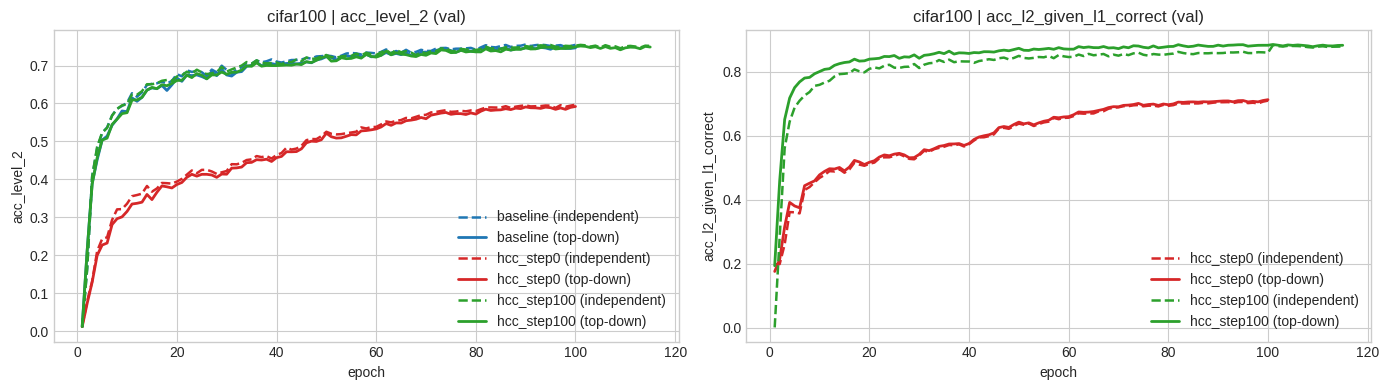

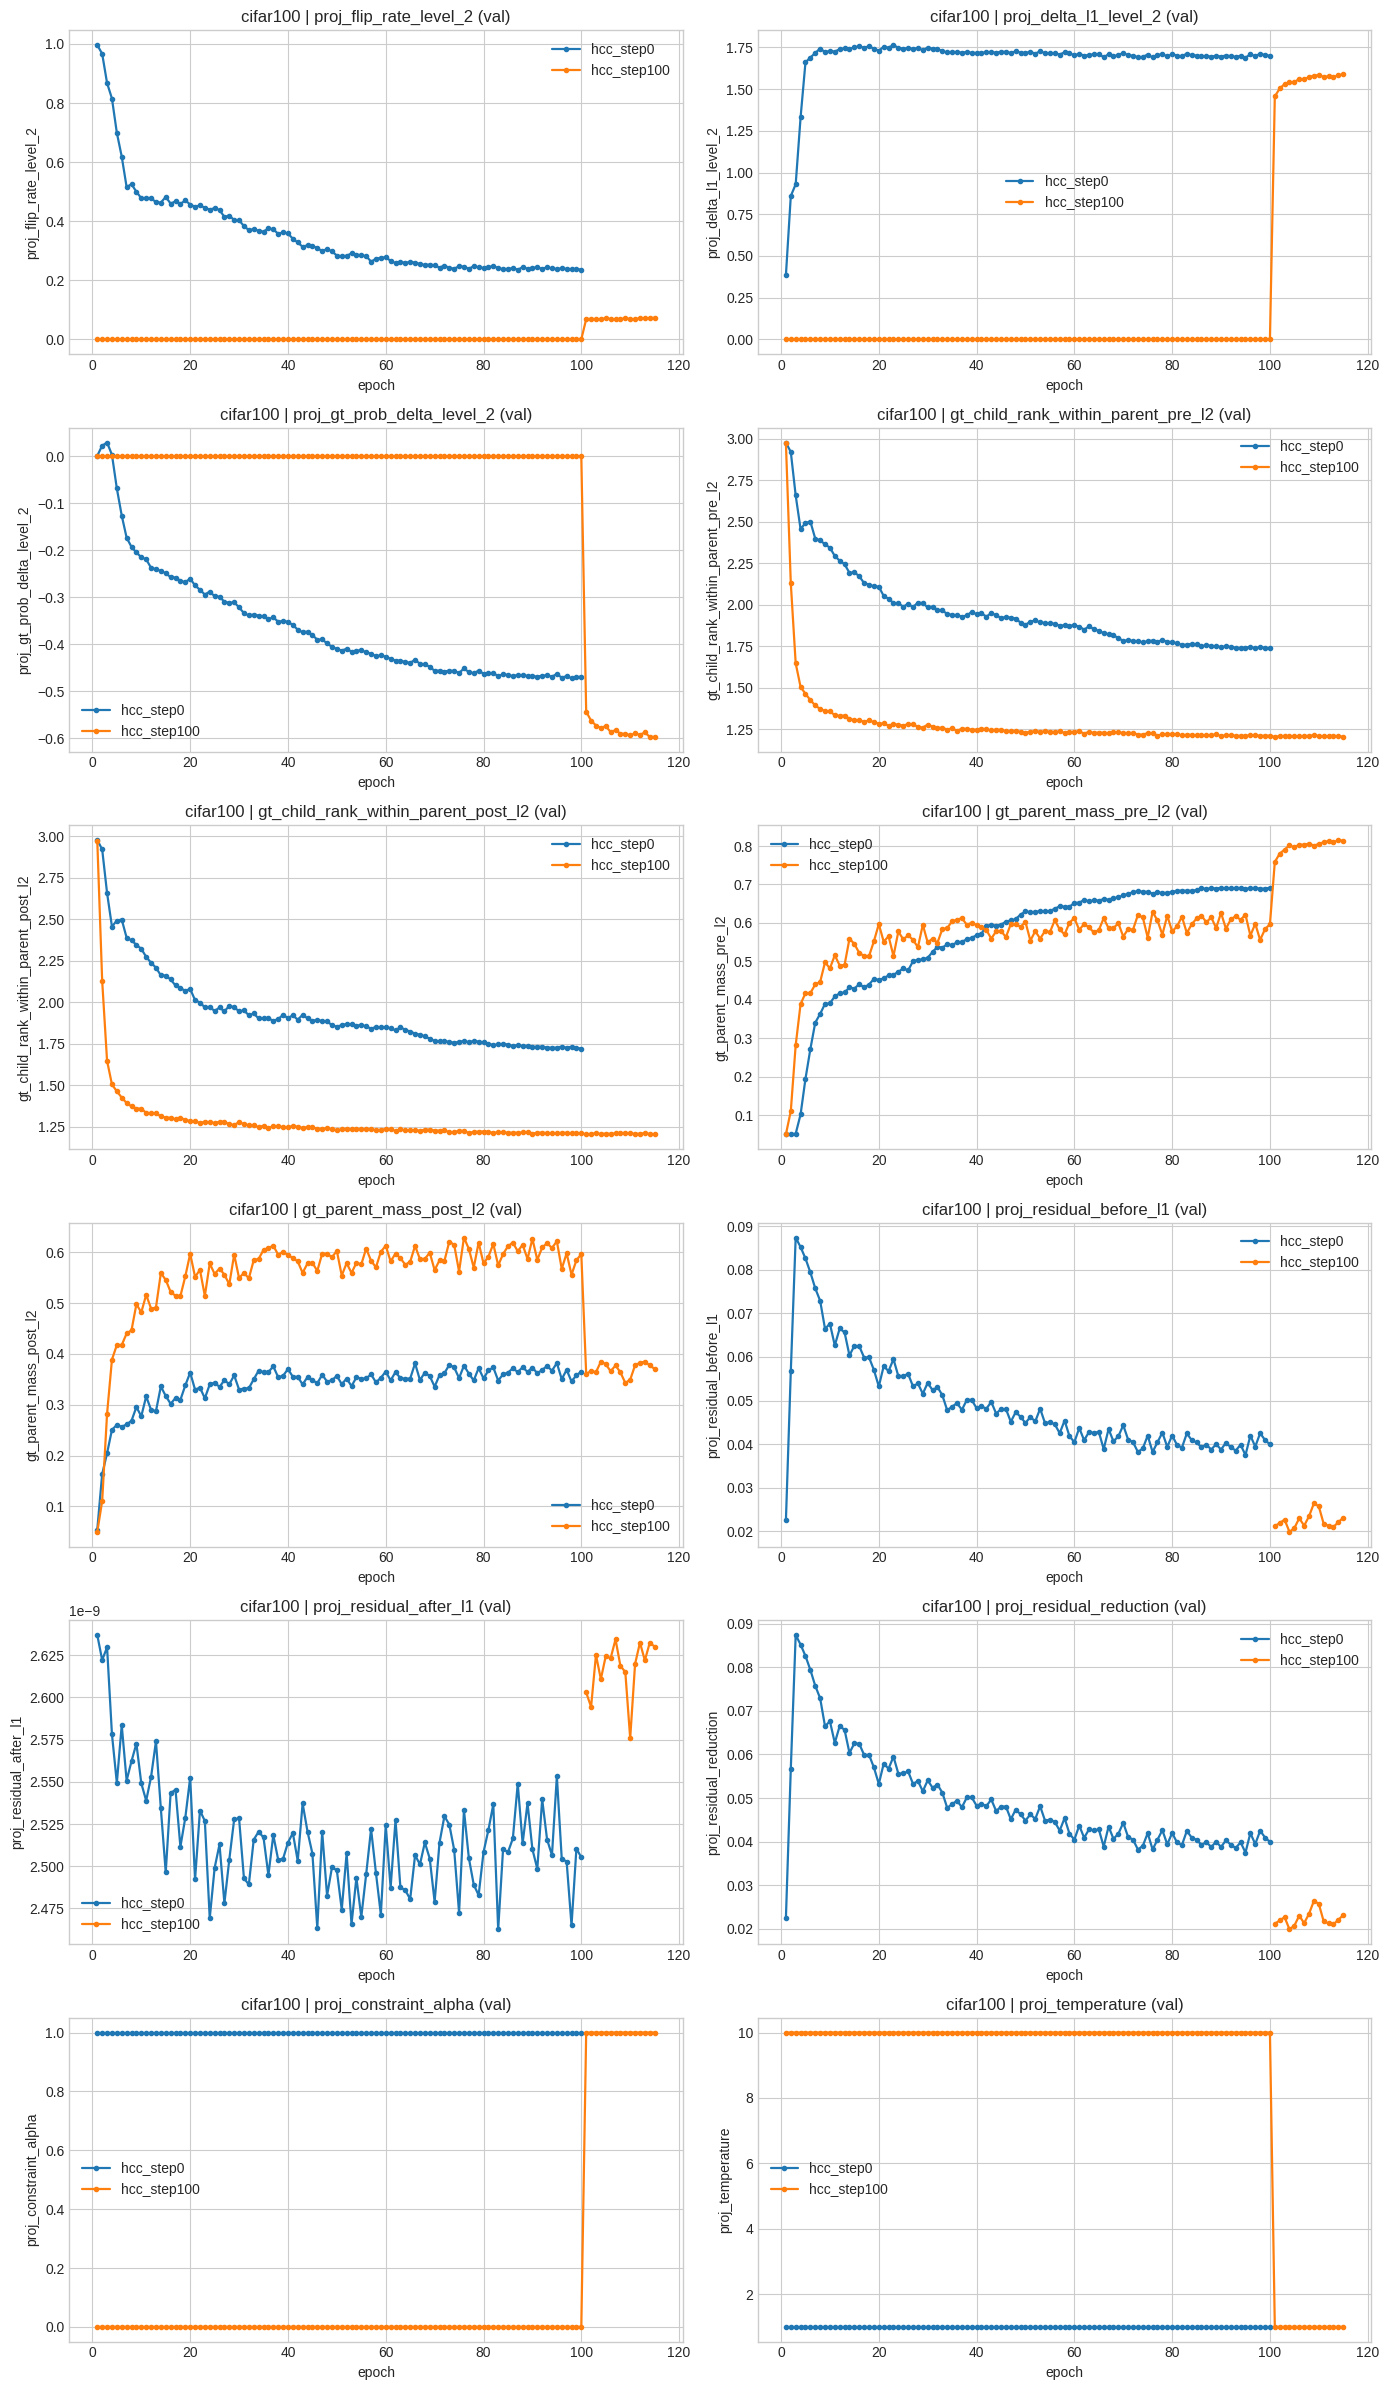

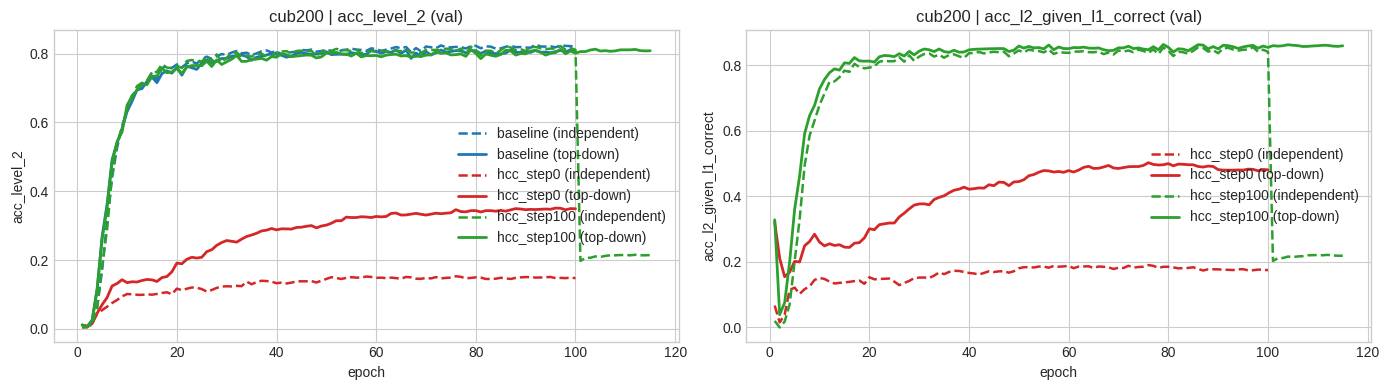

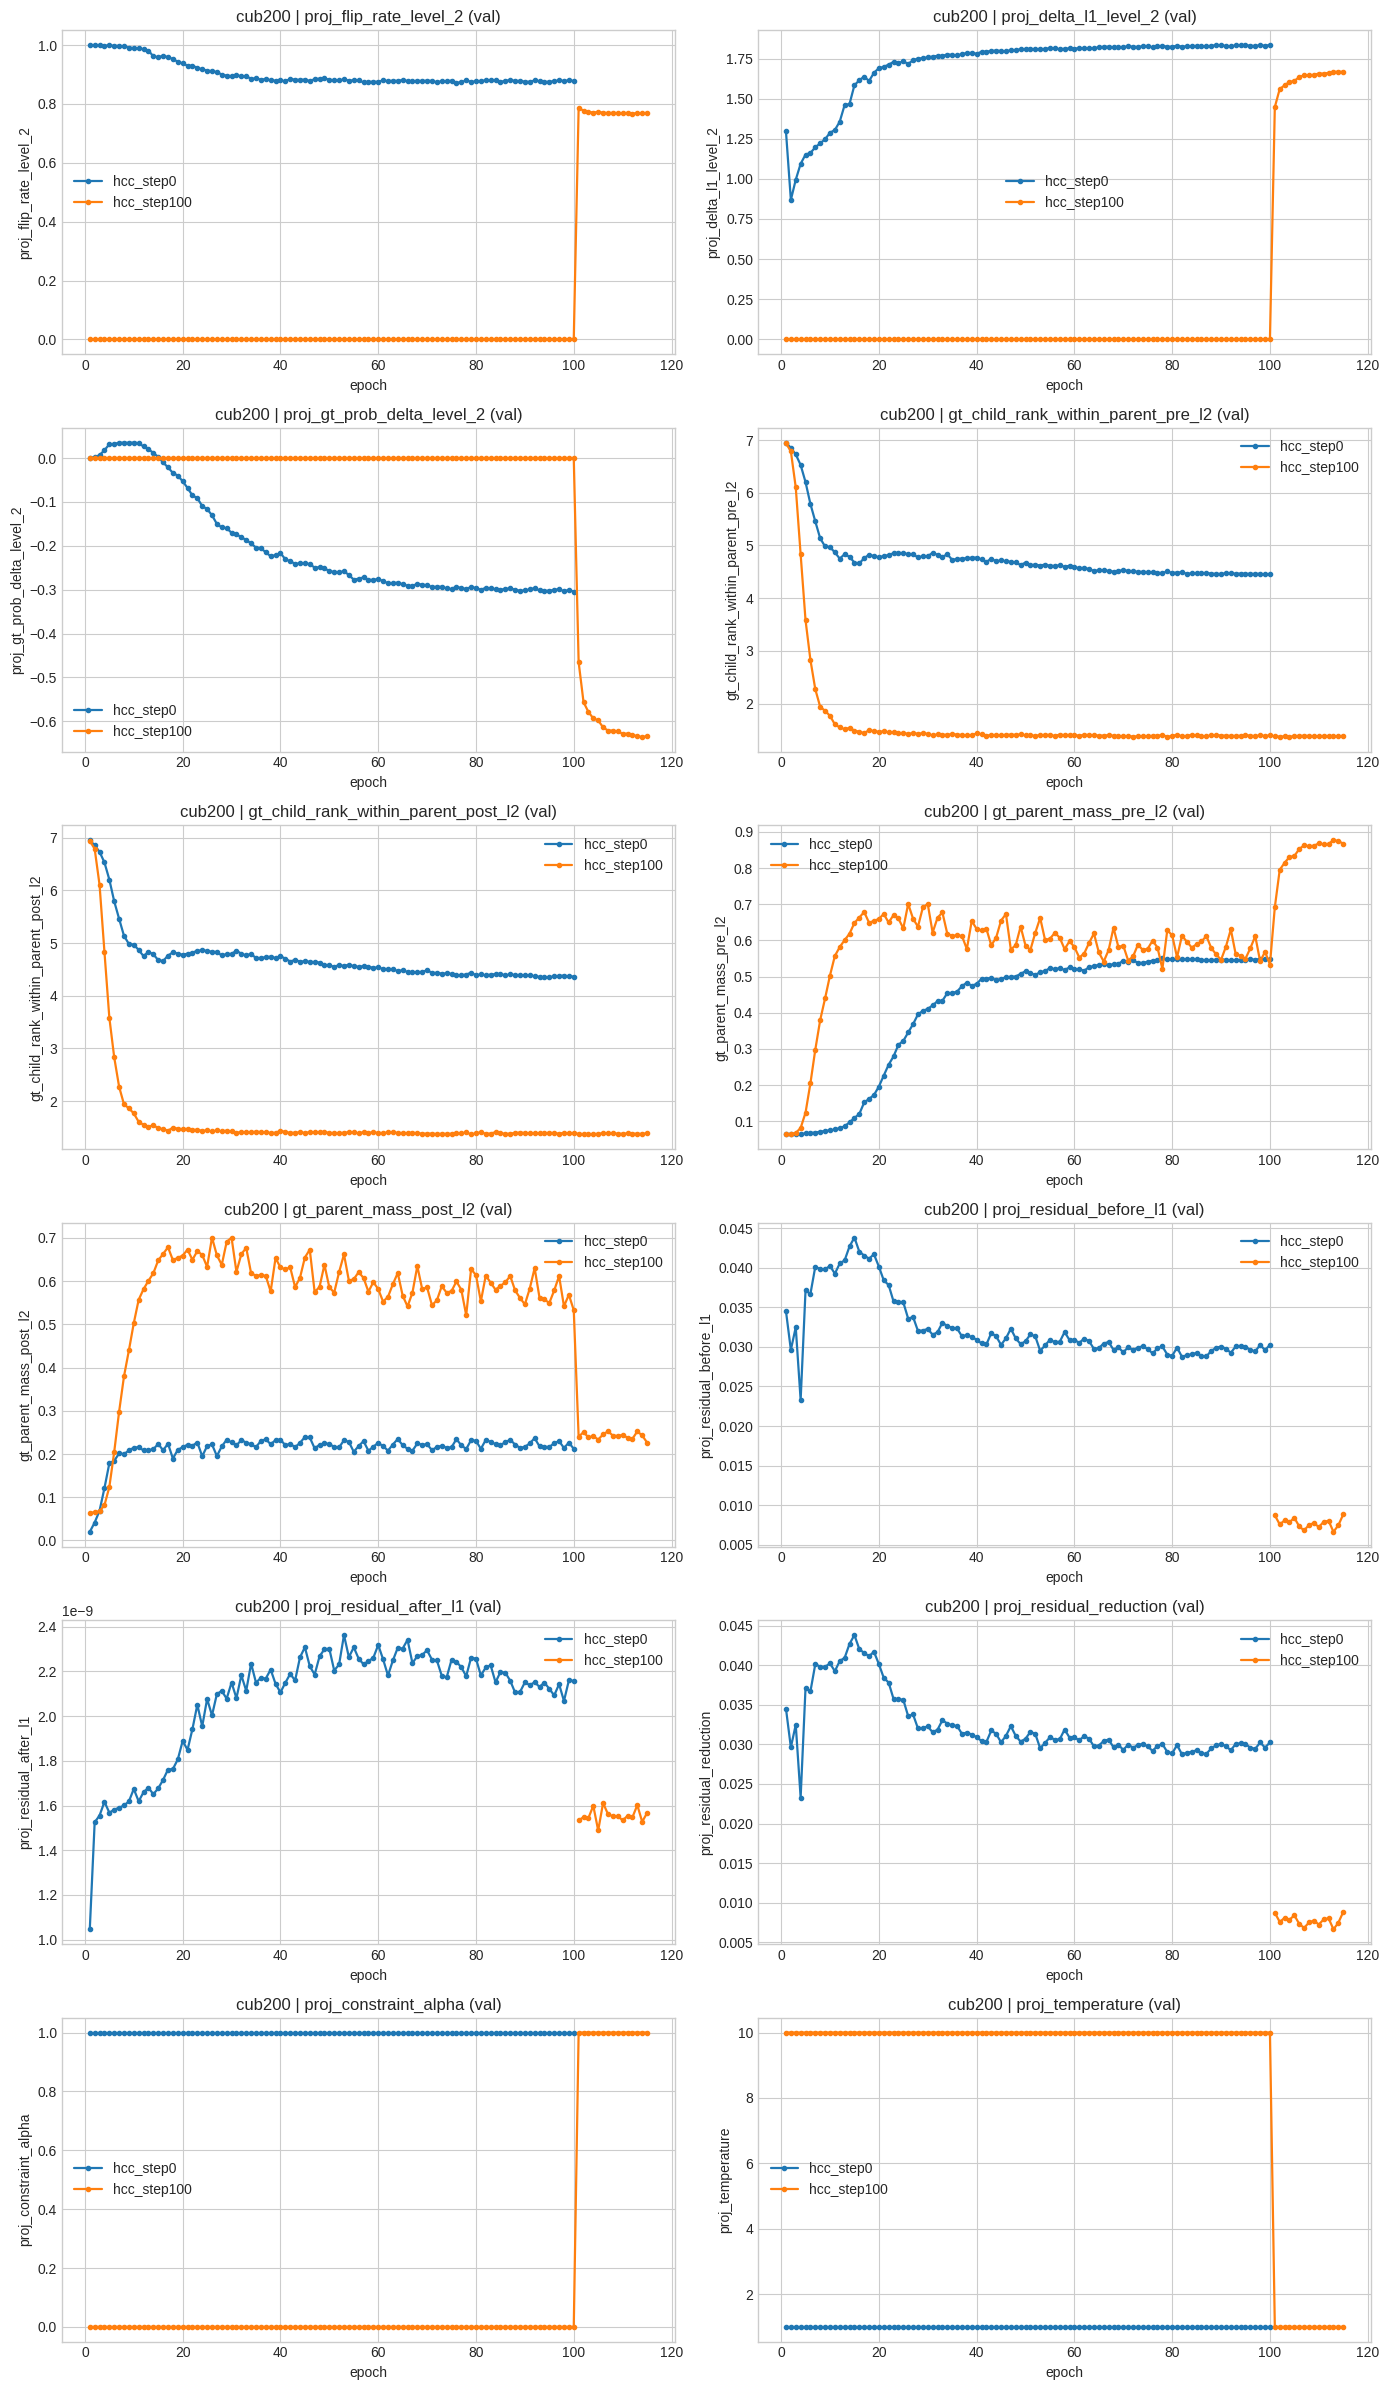

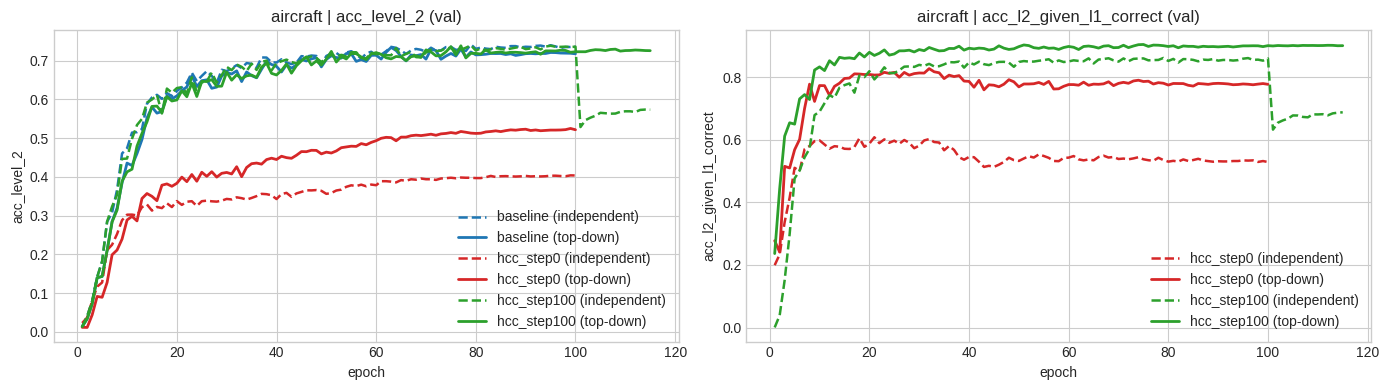

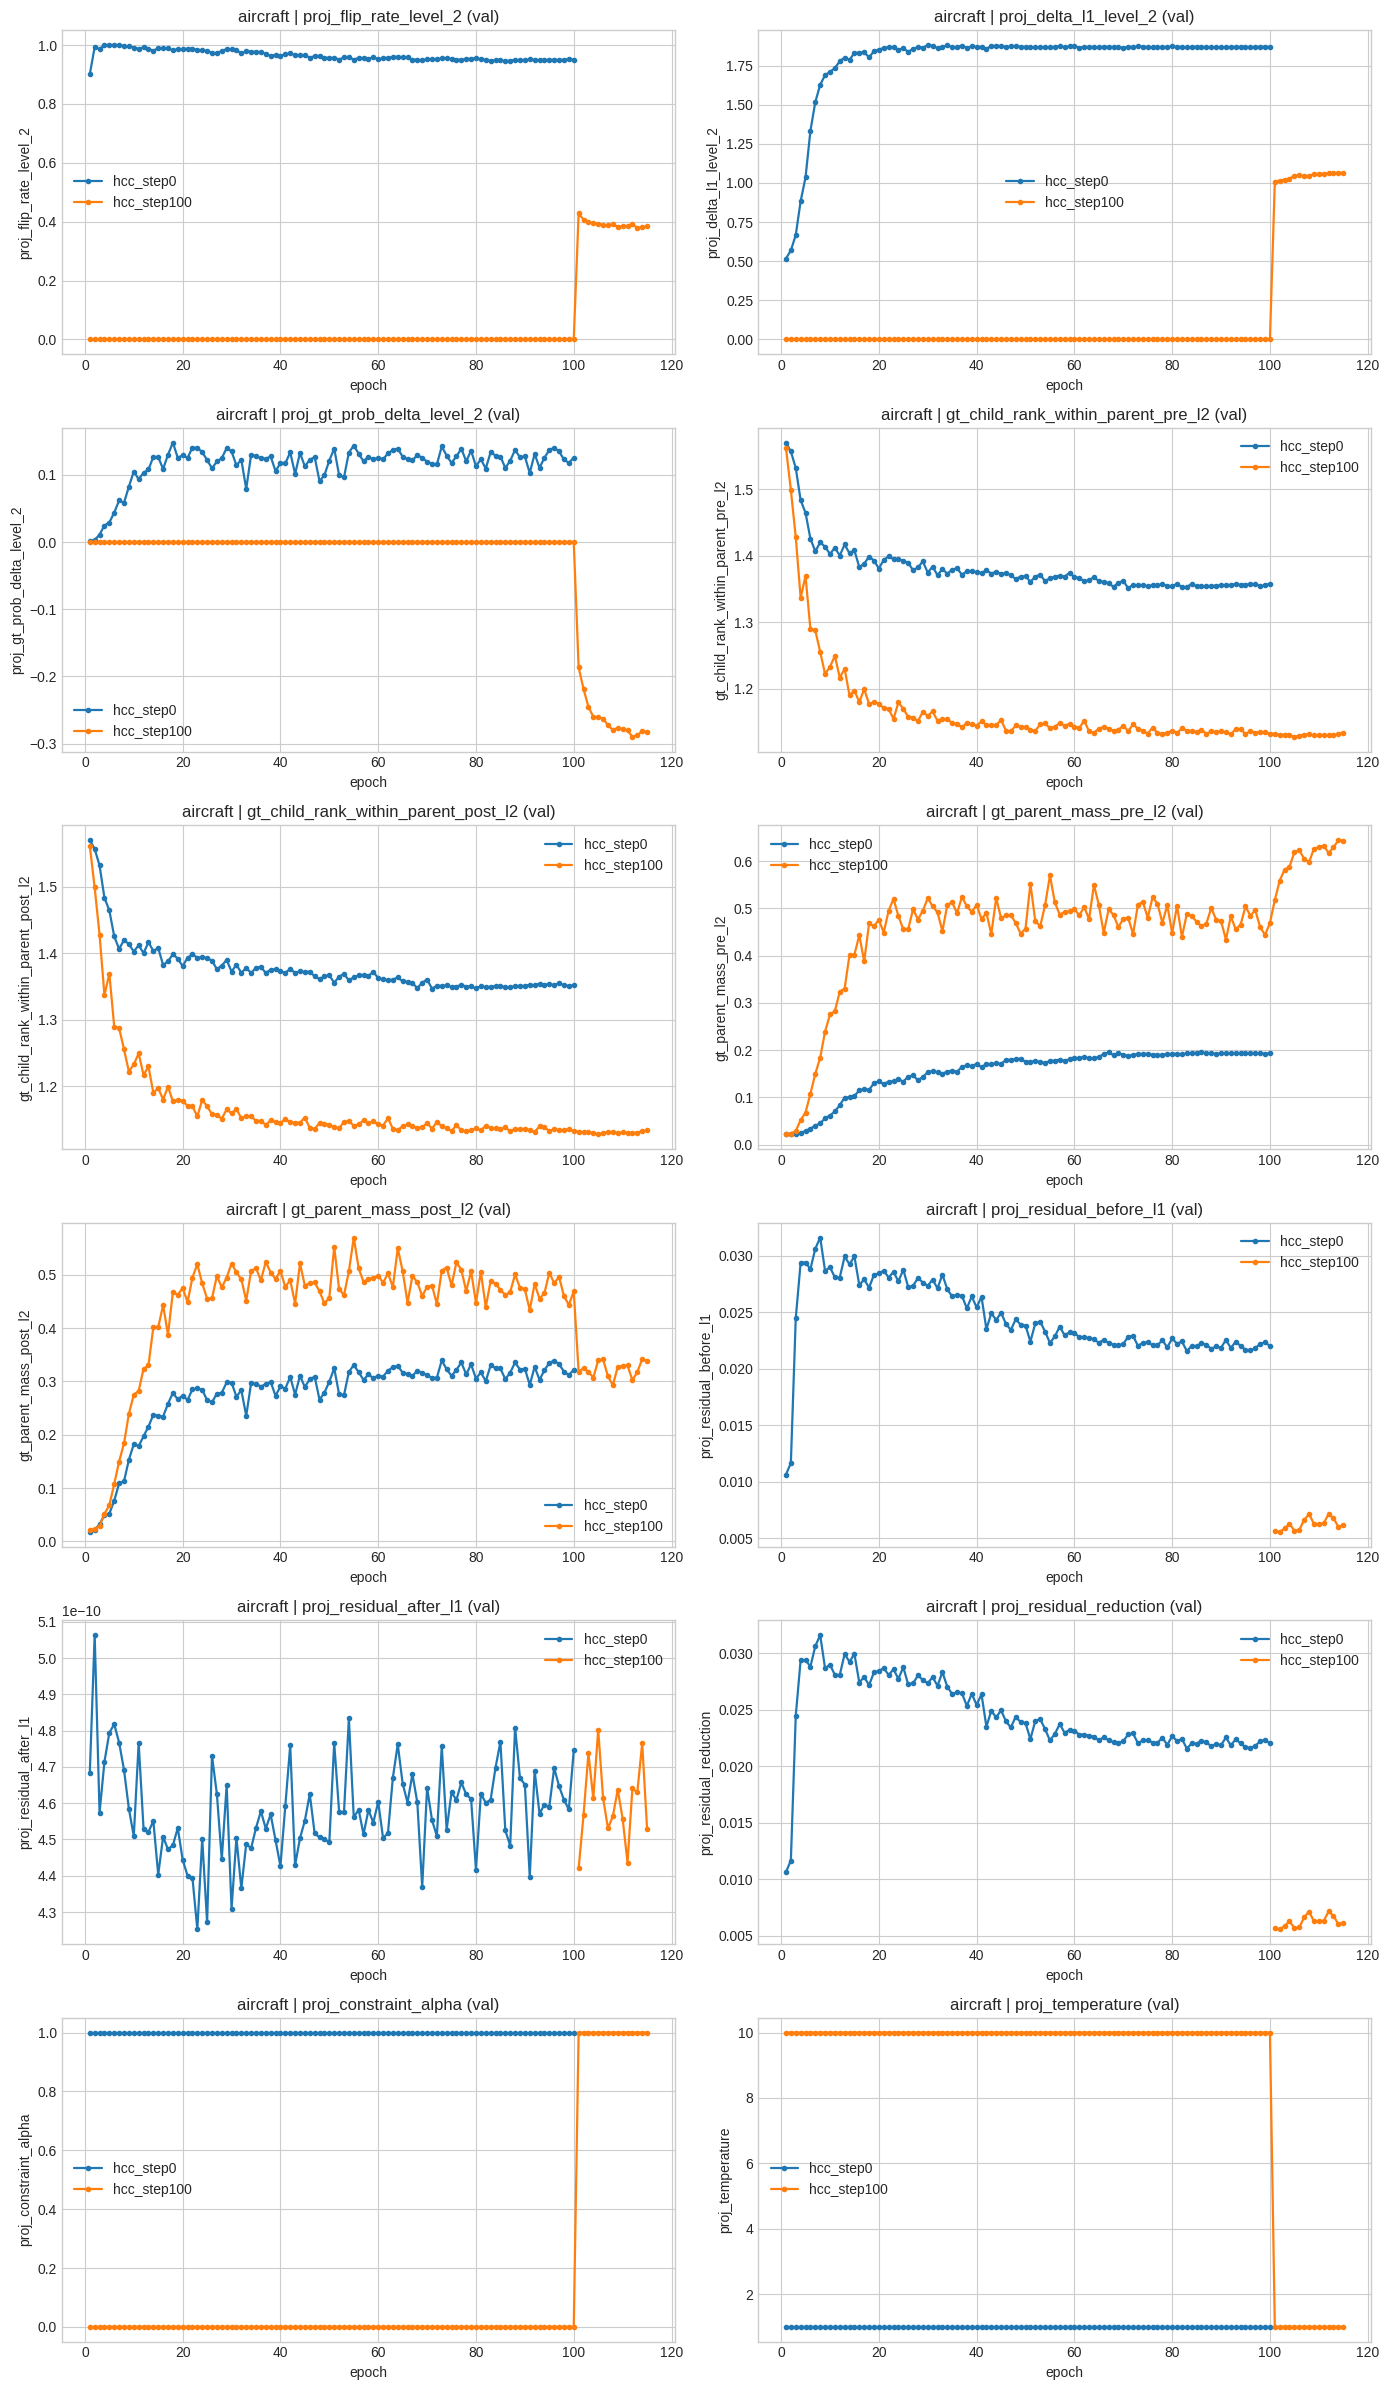

In [4]:
# 1) Overview of main metrics (val)
for ds in ['cifar100', 'cub200', 'aircraft']:
    # independent vs top-down in the same panel
    plot_mode_pairs(
        ds,
        pair_specs=[
            ('acc_level_independent_2', 'acc_level_topdown_2', 'acc_level_2'),
            ('acc_l2_ind_given_l1_correct', 'acc_l2_td_given_l1_correct', 'acc_l2_given_l1_correct'),
        ],
        split='val',
    )

    # Other HCC diagnostics
    plot_metric_grid(
        ds,
        metrics=[
            'proj_flip_rate_level_2',
            'proj_delta_l1_level_2',
            'proj_gt_prob_delta_level_2',
            'gt_child_rank_within_parent_pre_l2',
            'gt_child_rank_within_parent_post_l2',
            'gt_parent_mass_pre_l2',
            'gt_parent_mass_post_l2',
            'proj_residual_before_l1',
            'proj_residual_after_l1',
            'proj_residual_reduction',
            'proj_constraint_alpha',
            'proj_temperature',
        ],
        split='val',
    )


In [5]:
# 2) Zoom around the switch (step@100 only, epochs 95-105)
def switch_table(dataset_key: str, metrics, pre_epoch=100, post_epoch=101):
    run_dir = RUN_GROUPS[dataset_key]['hcc_step100']
    df = events_to_epoch_df(run_dir, split='val')
    if df.empty:
        print(f'No val epochs for {dataset_key} step@100')
        return pd.DataFrame()

    out_rows = []
    pre = df[df['epoch'] == pre_epoch]
    post = df[df['epoch'] == post_epoch]
    if pre.empty or post.empty:
        print(f'Missing epoch {pre_epoch} or {post_epoch} for {dataset_key}')
        return pd.DataFrame()

    for m in metrics:
        if m not in df.columns:
            continue
        pre_v = float(pre.iloc[0][m])
        post_v = float(post.iloc[0][m])
        out_rows.append({'metric': m, f'e{pre_epoch}': pre_v, f'e{post_epoch}': post_v, 'delta': post_v - pre_v})
    out = pd.DataFrame(out_rows)
    return out

for ds in ['cifar100', 'cub200', 'aircraft']:
    print(f'\n=== {ds} switch 100 -> 101 ===')
    display(switch_table(ds, [
        'proj_constraint_alpha',
        'proj_temperature',
        'loss_level_2',
        'gk_loss',
        'proj_flip_rate_level_2',
        'proj_delta_l1_level_2',
        'acc_level_independent_2',
        'acc_level_topdown_2',
        'acc_l2_ind_given_l1_correct',
        'acc_l2_td_given_l1_correct',
        'gt_child_rank_within_parent_pre_l2',
        'gt_child_rank_within_parent_post_l2',
    ]))



=== cifar100 switch 100 -> 101 ===


,metric,e100,e101,delta
0,proj_constraint_alpha,0.000000,1.000000,1.000000
1,proj_temperature,10.000000,1.000000,-9.000000
2,proj_flip_rate_level_2,0.000000,0.068652,0.068652
3,proj_delta_l1_level_2,0.000000,1.456004,1.456004
4,acc_level_independent_2,0.752441,0.754395,0.001953
5,acc_level_topdown_2,0.749414,0.751465,0.002051
6,acc_l2_ind_given_l1_correct,0.859379,0.882838,0.023459
7,acc_l2_td_given_l1_correct,0.882513,0.884951,0.002439
8,gt_child_rank_within_parent_pre_l2,1.212598,1.205273,-0.007324
9,gt_child_rank_within_parent_post_l2,1.212598,1.205273,-0.007324



=== cub200 switch 100 -> 101 ===


,metric,e100,e101,delta
0,proj_constraint_alpha,0.000000,1.000000,1.000000
1,proj_temperature,10.000000,1.000000,-9.000000
2,proj_flip_rate_level_2,0.000000,0.785582,0.785582
3,proj_delta_l1_level_2,0.000000,1.447378,1.447378
4,acc_level_independent_2,0.811222,0.197372,-0.613849
5,acc_level_topdown_2,0.801420,0.806108,0.004688
6,acc_l2_ind_given_l1_correct,0.840528,0.202757,-0.637772
7,acc_l2_td_given_l1_correct,0.853711,0.859111,0.005400
8,gt_child_rank_within_parent_pre_l2,1.395028,1.376562,-0.018466
9,gt_child_rank_within_parent_post_l2,1.395028,1.376562,-0.018466



=== aircraft switch 100 -> 101 ===


,metric,e100,e101,delta
0,proj_constraint_alpha,0.000000,1.000000,1.000000
1,proj_temperature,10.000000,1.000000,-9.000000
2,proj_flip_rate_level_2,0.000000,0.428348,0.428348
3,proj_delta_l1_level_2,0.000000,1.007261,1.007261
4,acc_level_independent_2,0.736049,0.528404,-0.207645
5,acc_level_topdown_2,0.722879,0.722879,0.000000
6,acc_l2_ind_given_l1_correct,0.860394,0.632848,-0.227546
7,acc_l2_td_given_l1_correct,0.901419,0.900443,-0.000976
8,gt_child_rank_within_parent_pre_l2,1.131975,1.131417,-0.000558
9,gt_child_rank_within_parent_post_l2,1.131975,1.131417,-0.000558



### cub200 train diagnostics


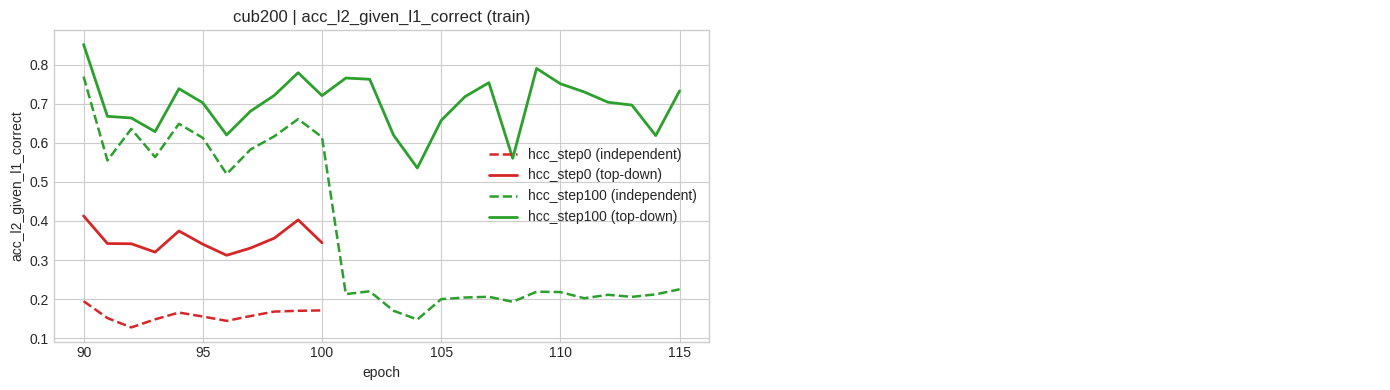

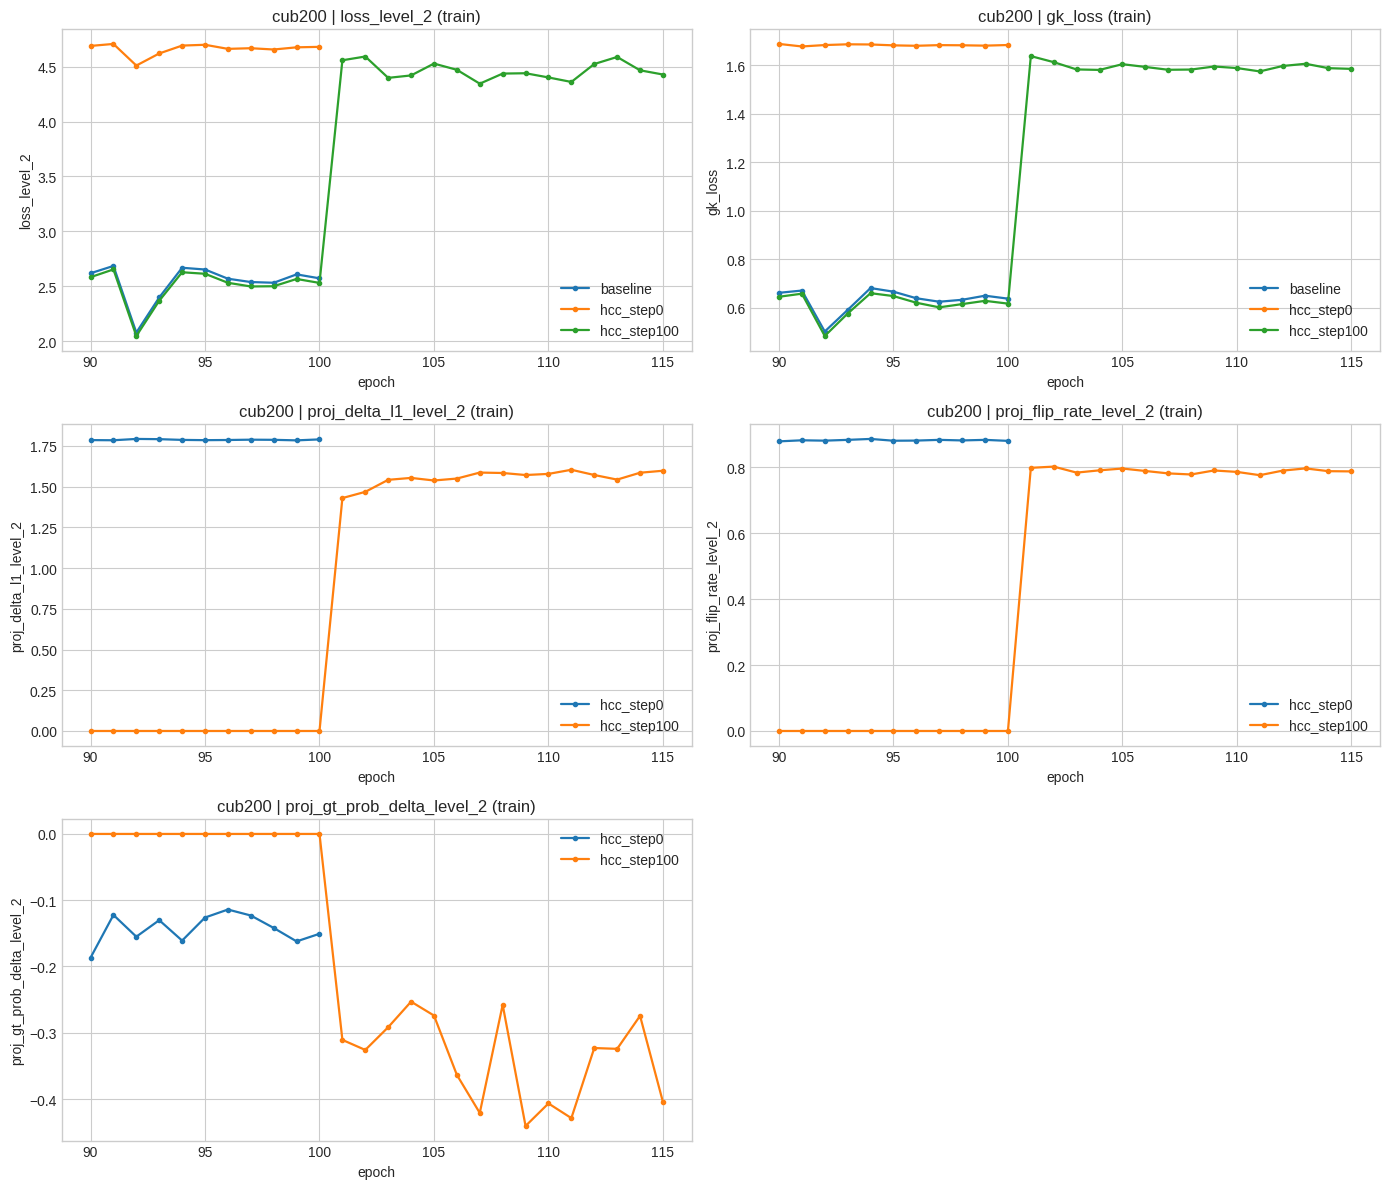


### aircraft train diagnostics


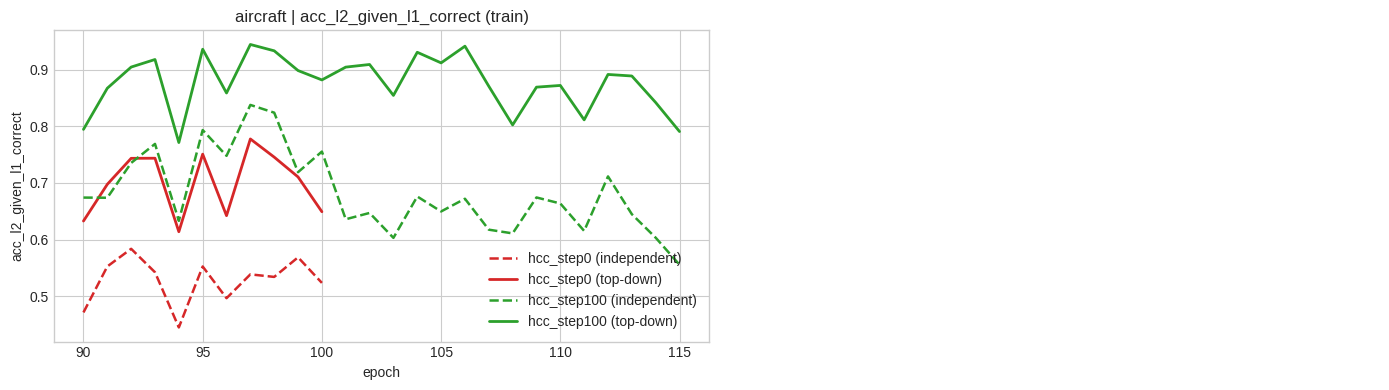

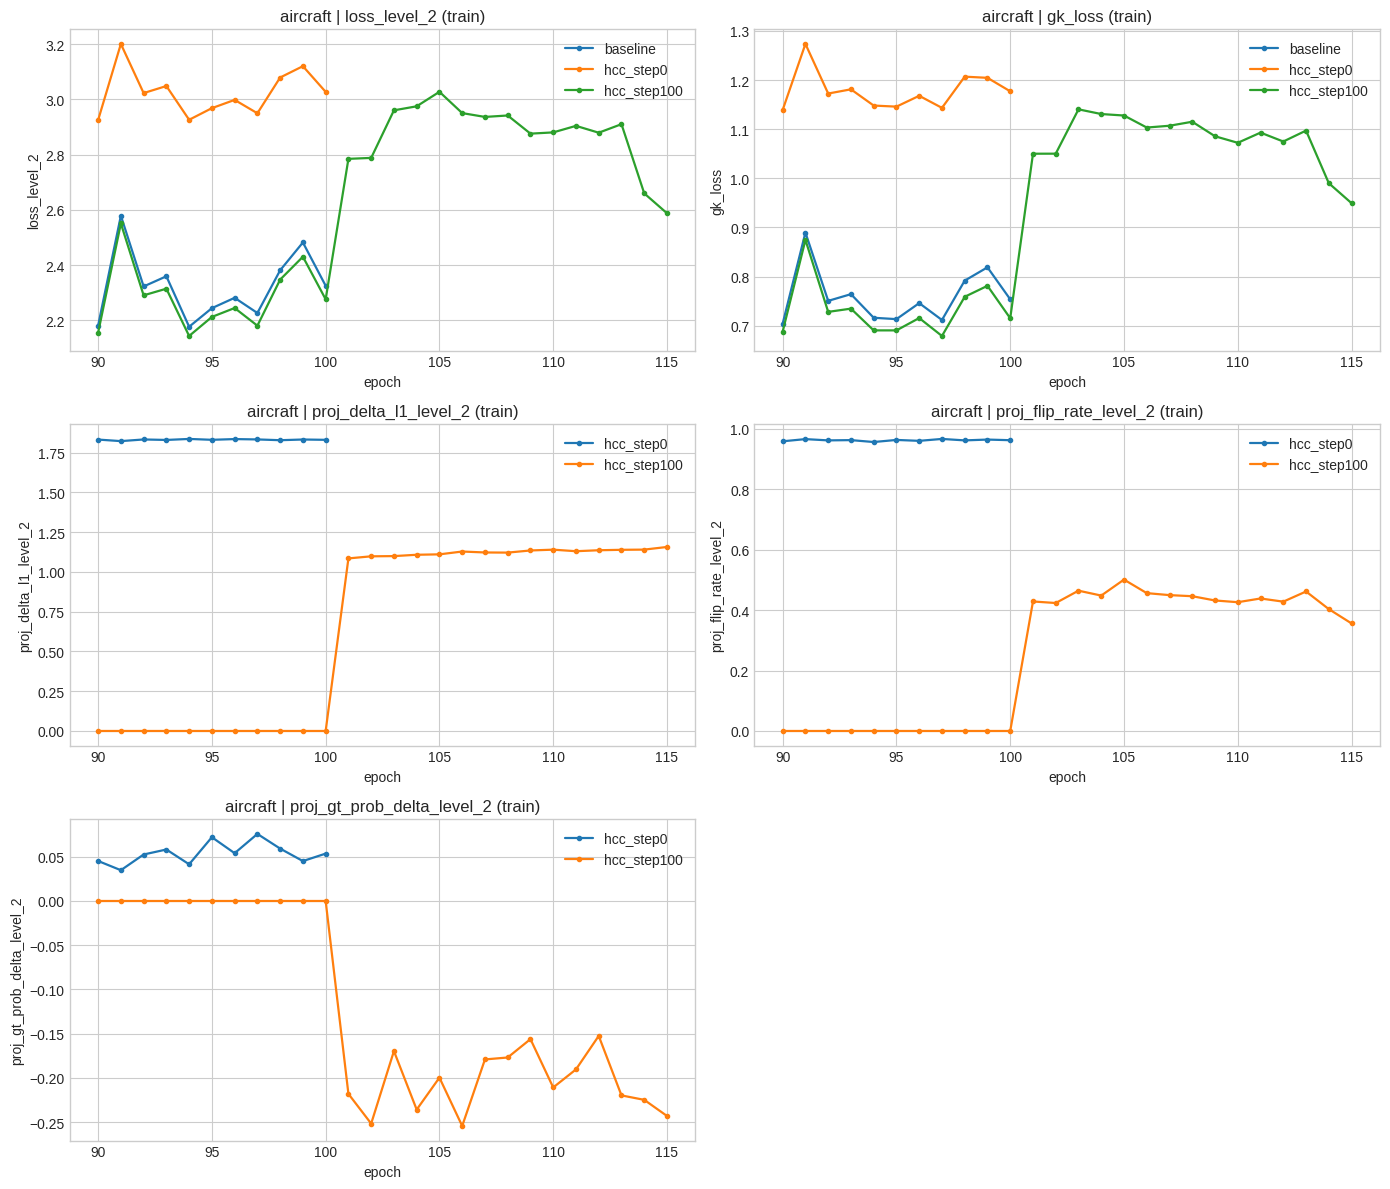

In [6]:
# 3) Train vs Val to inspect optimization/decoding mismatch
for ds in ['cub200', 'aircraft']:
    print(f'\n### {ds} train diagnostics')

    # independent vs top-down in the same panel
    plot_mode_pairs(
        ds,
        pair_specs=[
            ('acc_l2_ind_given_l1_correct', 'acc_l2_td_given_l1_correct', 'acc_l2_given_l1_correct'),
        ],
        split='train',
        epoch_min=90,
    )

    # Loss/projection
    plot_metric_grid(
        ds,
        metrics=[
            'loss_level_2',
            'gk_loss',
            'proj_delta_l1_level_2',
            'proj_flip_rate_level_2',
            'proj_gt_prob_delta_level_2',
        ],
        split='train',
        epoch_min=90,
    )
